# 00 — Why Do We Need Embeddings?

## The Core Question
Why can't we just search text with `LIKE '%keyword%'` or `grep`? What problem do embeddings solve?

This notebook answers that question with **real Bedrock API calls**, live visualizations, and concrete side-by-side comparisons.

## What You'll See
| Section | What it shows |
|---------|---------------|
| 1 | Where keyword search fails |
| 2 | Real 1024-dim embeddings via Amazon Bedrock Titan V2 |
| 3 | PCA scatter — words/sentences cluster by **meaning** |
| 4 | Cosine similarity heatmap — semantic neighbours |
| 5 | Semantic vs keyword search comparison bar chart |
| 6 | Analogy arithmetic — `king − man + woman ≈ queen` |
| 7 | Why 1024 dimensions? Capacity analysis |

## Stack
- **Embeddings**: Amazon Bedrock `amazon.titan-embed-text-v2:0` (1024 dims)
- **Vector DB**: Qdrant (Cloud → in-memory fallback)
- **Visualization**: matplotlib, seaborn, sklearn PCA/t-SNE

## Step 1 — Install & Import

In [1]:
import subprocess, sys

packages = [
    "boto3",
    "qdrant-client",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "python-dotenv",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)
print("All packages ready.")

All packages ready.


In [2]:
from dotenv import load_dotenv
load_dotenv('../../../.env')  # load QDRANT_URL, QDRANT_API_KEY, AWS creds

import os, json, time, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import boto3

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#a0a0b0",
    "ytick.color":      "#a0a0b0",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2d3d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

print("Imports OK")

Imports OK


## Step 2 — Configuration & Bedrock Client

In [3]:
AWS_REGION      = os.getenv("AWS_DEFAULT_REGION", "us-east-1")
EMBEDDING_MODEL = "amazon.titan-embed-text-v2:0"   # 1024-dim
EMBEDDING_DIM   = 1024

QDRANT_URL      = os.getenv("QDRANT_URL",     "")
QDRANT_API_KEY  = os.getenv("QDRANT_API_KEY", "")

bedrock_rt = boto3.client("bedrock-runtime", region_name=AWS_REGION)

def embed(text: str) -> np.ndarray:
    """Return a 1024-dim unit-norm embedding via Amazon Bedrock Titan V2."""
    body = json.dumps({"inputText": text, "dimensions": EMBEDDING_DIM, "normalize": True})
    resp = bedrock_rt.invoke_model(
        modelId=EMBEDDING_MODEL, body=body,
        contentType="application/json", accept="application/json"
    )
    return np.array(json.loads(resp["body"].read())["embedding"], dtype=np.float32)


def embed_batch(texts: list, delay: float = 0.05) -> np.ndarray:
    vecs = []
    for i, t in enumerate(texts):
        vecs.append(embed(t))
        time.sleep(delay)
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(texts)} embedded")
    return np.vstack(vecs)   # shape (N, 1024)


# Smoke test
v = embed("hello world")
print(f"Embedding dim : {v.shape[0]}")
print(f"L2 norm       : {np.linalg.norm(v):.6f}  (should be 1.0 — unit-normalized)")
print(f"First 5 values: {v[:5].tolist()}")

Embedding dim : 1024
L2 norm       : 1.000000  (should be 1.0 — unit-normalized)
First 5 values: [-0.02060231938958168, 0.05661262199282646, 0.007168131414800882, -0.009022098034620285, 0.039273928850889206]


## Step 3 — The Problem Keyword Search Cannot Solve

Keyword search matches **character sequences**, not **meaning**.

| Query | Keyword result | Semantic result |
|-------|---------------|-----------------|
| `"car"` | finds `"car"` only | finds `"automobile"`, `"vehicle"`, `"sedan"` too |
| `"cheap flights"` | misses `"budget airfare"` | finds it |
| `"heart attack"` | misses `"myocardial infarction"` | finds it |

Below we **measure** this gap with real Bedrock embeddings.

In [4]:
# ── Pairs: (query, candidate, expected=RELEVANT/IRRELEVANT) ─────────────────
pairs = [
    # Same meaning, zero shared words
    ("car",                        "automobile",              "RELEVANT"),
    ("cheap flights",              "budget airfare deals",    "RELEVANT"),
    ("heart attack",               "myocardial infarction",   "RELEVANT"),
    ("I am happy",                 "I feel joyful",           "RELEVANT"),
    ("software bug",               "code defect",             "RELEVANT"),

    # Same words, totally different meaning
    ("bank",                       "river bank deposit",      "AMBIGUOUS"),

    # Clearly unrelated (high keyword overlap possible)
    ("I love playing football",    "football stadium capacity","IRRELEVANT"),
    ("machine learning model",     "fashion model runway",    "IRRELEVANT"),
]

# Real API calls
print("Calling Bedrock Titan V2 for each pair...")
results = []
for query, candidate, label in pairs:
    q_vec = embed(query)
    c_vec = embed(candidate)
    cos   = float(np.dot(q_vec, c_vec))   # already unit-normalised → cosine = dot

    # Keyword overlap score (Jaccard on word sets)
    q_words = set(query.lower().split())
    c_words = set(candidate.lower().split())
    jaccard  = len(q_words & c_words) / len(q_words | c_words) if q_words | c_words else 0

    results.append((query, candidate, label, cos, jaccard))
    print(f"  [{label:10s}]  cos={cos:.3f}  kw={jaccard:.3f}  |  '{query}' vs '{candidate}'")

print("\nAPI calls complete.")

Calling Bedrock Titan V2 for each pair...


  [RELEVANT  ]  cos=0.588  kw=0.000  |  'car' vs 'automobile'


  [RELEVANT  ]  cos=0.761  kw=0.000  |  'cheap flights' vs 'budget airfare deals'


  [RELEVANT  ]  cos=0.304  kw=0.000  |  'heart attack' vs 'myocardial infarction'


  [RELEVANT  ]  cos=0.639  kw=0.200  |  'I am happy' vs 'I feel joyful'


  [RELEVANT  ]  cos=0.434  kw=0.000  |  'software bug' vs 'code defect'


  [AMBIGUOUS ]  cos=0.383  kw=0.333  |  'bank' vs 'river bank deposit'


  [IRRELEVANT]  cos=0.188  kw=0.167  |  'I love playing football' vs 'football stadium capacity'


  [IRRELEVANT]  cos=0.116  kw=0.200  |  'machine learning model' vs 'fashion model runway'

API calls complete.


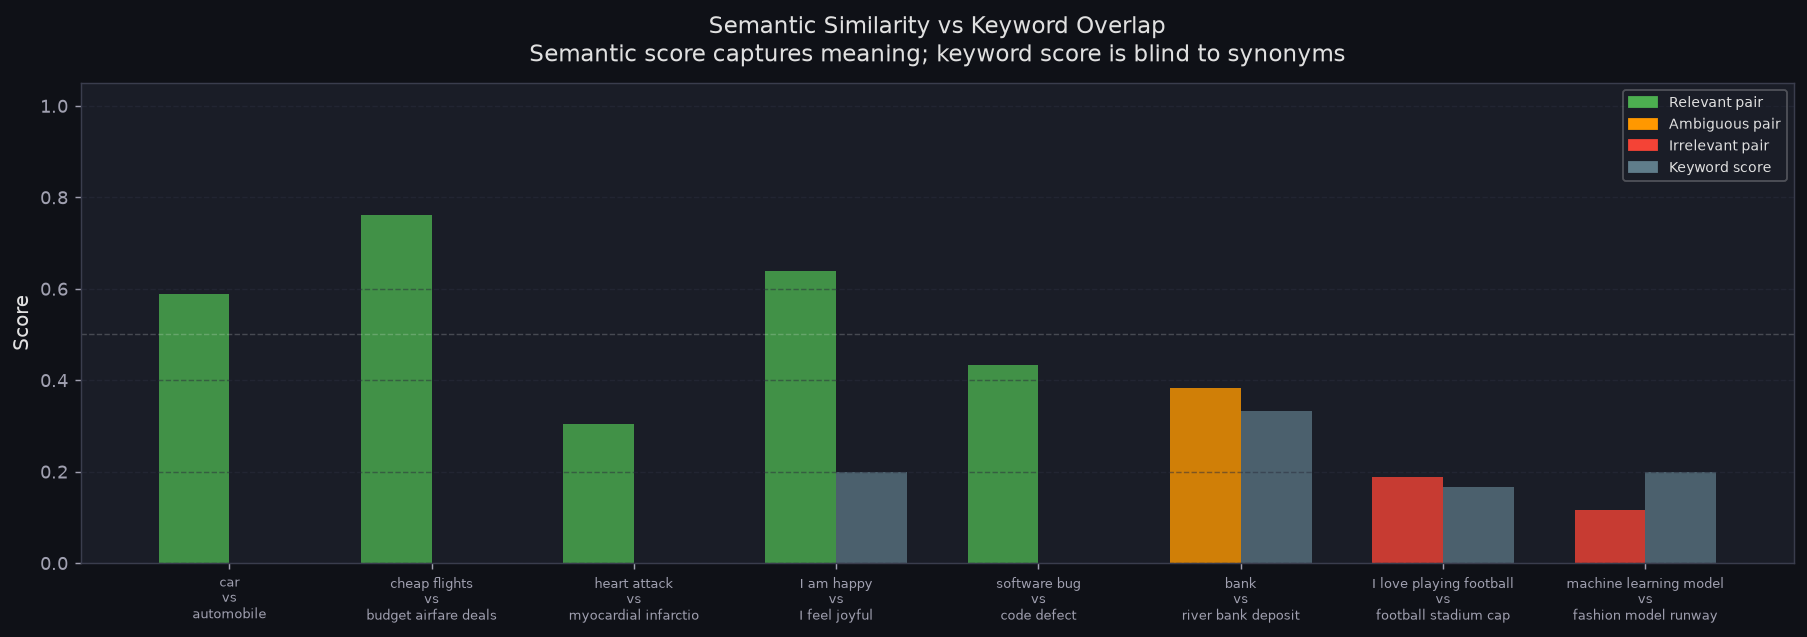

Saved: 01_semantic_vs_keyword.png


In [5]:
# ── Visualisation: Semantic vs Keyword score side-by-side ────────────────────
labels   = [f"{r[0]}\nvs\n{r[1][:20]}" for r in results]
cos_vals = [r[3] for r in results]
kw_vals  = [r[4] for r in results]
colors   = ["#4CAF50" if r[2]=="RELEVANT" else ("#FF9800" if r[2]=="AMBIGUOUS" else "#F44336")
            for r in results]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - w/2, cos_vals, w, label="Semantic (cosine)", color=[c + "CC" for c in colors])
bars2 = ax.bar(x + w/2, kw_vals,  w, label="Keyword (Jaccard)",  color="#607D8B", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7, ha="center")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Semantic Similarity vs Keyword Overlap\n"
             "Semantic score captures meaning; keyword score is blind to synonyms", pad=12)
ax.axhline(0.5, color="#ffffff33", linestyle="--", linewidth=0.8)
ax.legend(loc="upper right", framealpha=0.3)
ax.grid(axis="y")

patches = [
    mpatches.Patch(color="#4CAF50", label="Relevant pair"),
    mpatches.Patch(color="#FF9800", label="Ambiguous pair"),
    mpatches.Patch(color="#F44336", label="Irrelevant pair"),
]
ax.legend(handles=patches + [mpatches.Patch(color="#607D8B", label="Keyword score")],
          loc="upper right", framealpha=0.3, fontsize=8)

fig.tight_layout()
plt.savefig("01_semantic_vs_keyword.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 01_semantic_vs_keyword.png")

**Key insight** — Semantic similarity (blue/green bars) correctly scores RELEVANT pairs high
even when they share *zero words*. Keyword Jaccard (grey bars) scores them all zero.

This is the core reason we need embeddings in RAG.

## Step 4 — PCA Scatter: Embeddings Cluster by Meaning

We embed 30 sentences spanning 5 topics, then project the 1024-dim vectors down to 2D
with PCA. Sentences about the **same topic** should land near each other — with zero
handcrafted rules.

In [6]:
# ── 30 sentences across 5 topics ─────────────────────────────────────────────
topic_sentences = {
    "Space & Astronomy": [
        "The Milky Way is a spiral galaxy.",
        "Black holes have enormous gravitational pull.",
        "NASA launched the James Webb Space Telescope.",
        "Mars has two small moons, Phobos and Deimos.",
        "The Big Bang theory explains the origin of the universe.",
        "Neutron stars are incredibly dense stellar remnants.",
    ],
    "Cooking & Food": [
        "Pasta is best cooked al dente.",
        "Sautéing garlic in olive oil adds depth of flavour.",
        "Fermentation is used to make bread and beer.",
        "Fresh herbs brighten any dish.",
        "A roux is used to thicken sauces and soups.",
        "Umami is often called the fifth taste.",
    ],
    "Machine Learning": [
        "Gradient descent optimises neural network weights.",
        "Overfitting occurs when a model memorises training data.",
        "Transformers use self-attention mechanisms.",
        "Regularisation prevents overfitting in ML models.",
        "A confusion matrix evaluates classification performance.",
        "Backpropagation computes gradients for weight updates.",
    ],
    "Finance & Economics": [
        "Inflation erodes the purchasing power of money.",
        "Compound interest grows wealth exponentially.",
        "GDP measures the total economic output of a country.",
        "Diversification reduces investment portfolio risk.",
        "A recession is two consecutive quarters of negative growth.",
        "Central banks set interest rates to control inflation.",
    ],
    "Health & Medicine": [
        "Vaccines stimulate the immune system against pathogens.",
        "The heart pumps blood through the circulatory system.",
        "Antibiotics fight bacterial but not viral infections.",
        "Regular exercise reduces the risk of cardiovascular disease.",
        "MRI scans use magnetic fields to image soft tissue.",
        "The gut microbiome influences mental and physical health.",
    ],
}

# Flatten
all_sentences = [s for sentences in topic_sentences.values() for s in sentences]
all_labels    = [t for t, sentences in topic_sentences.items() for _ in sentences]

print(f"Embedding {len(all_sentences)} sentences via Bedrock Titan V2...")
t0 = time.time()
matrix = embed_batch(all_sentences)   # shape (30, 1024)
print(f"Done in {time.time()-t0:.1f}s  |  matrix shape: {matrix.shape}")

Embedding 30 sentences via Bedrock Titan V2...


  10/30 embedded


  20/30 embedded


  30/30 embedded
Done in 7.2s  |  matrix shape: (30, 1024)


PCA variance explained: PC1=5.8%  PC2=5.4%


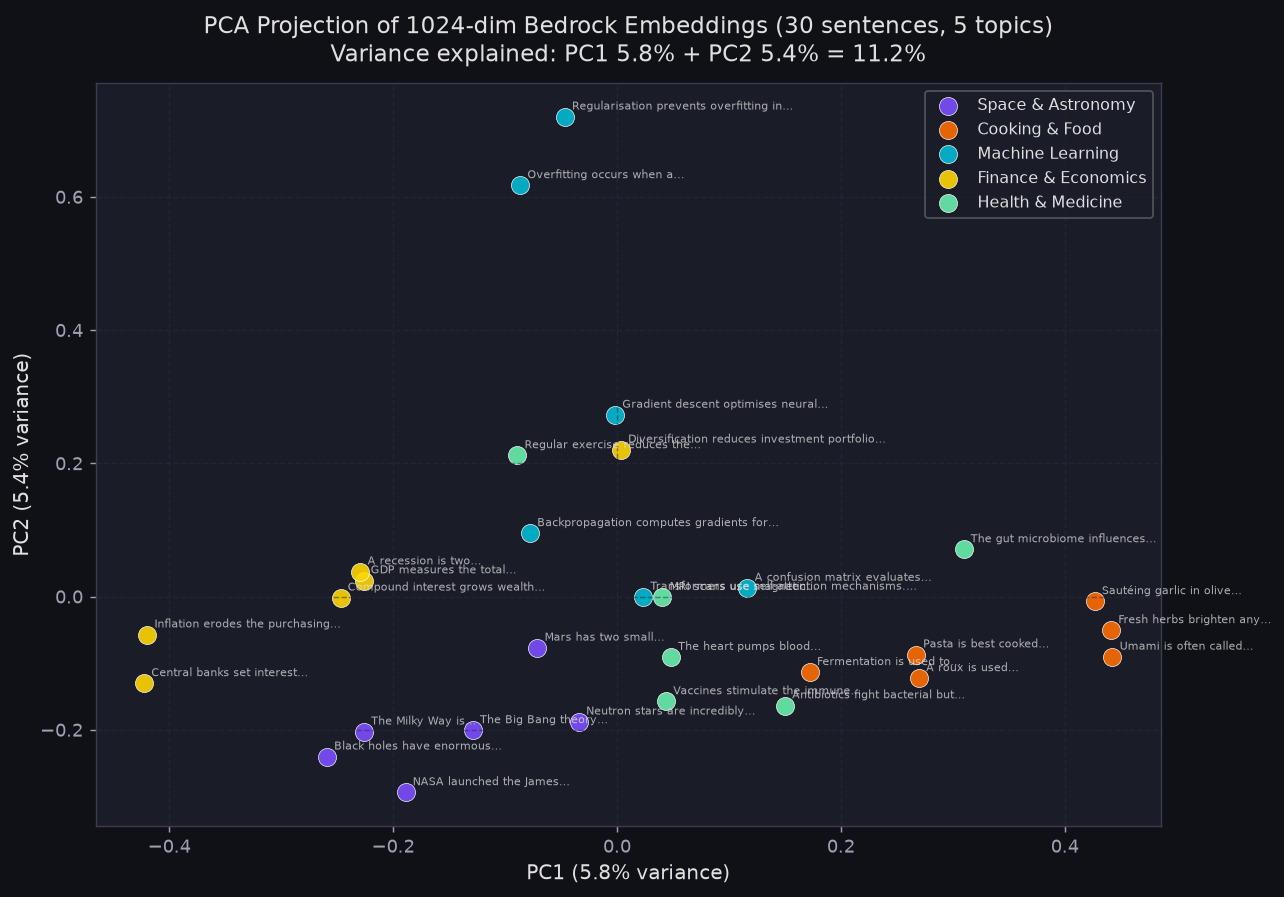

Saved: 02_pca_scatter.png


In [7]:
# ── PCA to 2D ────────────────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(matrix)   # (30, 2)
var_explained = pca.explained_variance_ratio_
print(f"PCA variance explained: PC1={var_explained[0]*100:.1f}%  PC2={var_explained[1]*100:.1f}%")

# ── Colour palette ────────────────────────────────────────────────────────────
palette = {
    "Space & Astronomy":  "#7C4DFF",
    "Cooking & Food":     "#FF6D00",
    "Machine Learning":   "#00BCD4",
    "Finance & Economics":"#FFD600",
    "Health & Medicine":  "#69F0AE",
}

fig, ax = plt.subplots(figsize=(10, 7))

for topic, color in palette.items():
    mask = [i for i, l in enumerate(all_labels) if l == topic]
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=color, s=100, alpha=0.9, label=topic, edgecolors="white", linewidths=0.4
    )
    # Label each point with a short version of the sentence
    for idx in mask:
        short = all_sentences[idx].split(" ")[:4]
        ax.annotate(
            " ".join(short) + "…",
            (coords[idx, 0], coords[idx, 1]),
            fontsize=6, alpha=0.75,
            xytext=(4, 4), textcoords="offset points"
        )

ax.set_title(
    "PCA Projection of 1024-dim Bedrock Embeddings (30 sentences, 5 topics)\n"
    f"Variance explained: PC1 {var_explained[0]*100:.1f}% + PC2 {var_explained[1]*100:.1f}% = "
    f"{sum(var_explained)*100:.1f}%",
    pad=12
)
ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance)")
ax.legend(loc="best", framealpha=0.3, fontsize=9)
ax.grid(True)

fig.tight_layout()
plt.savefig("02_pca_scatter.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 02_pca_scatter.png")

**What you see** — Sentences about the same topic cluster together in 2D, even though the
model never received labels. The geometry of the 1024-dim space encodes meaning.

## Step 5 — t-SNE: Better Cluster Separation

PCA is linear. t-SNE is non-linear and often shows tighter, more separated clusters.

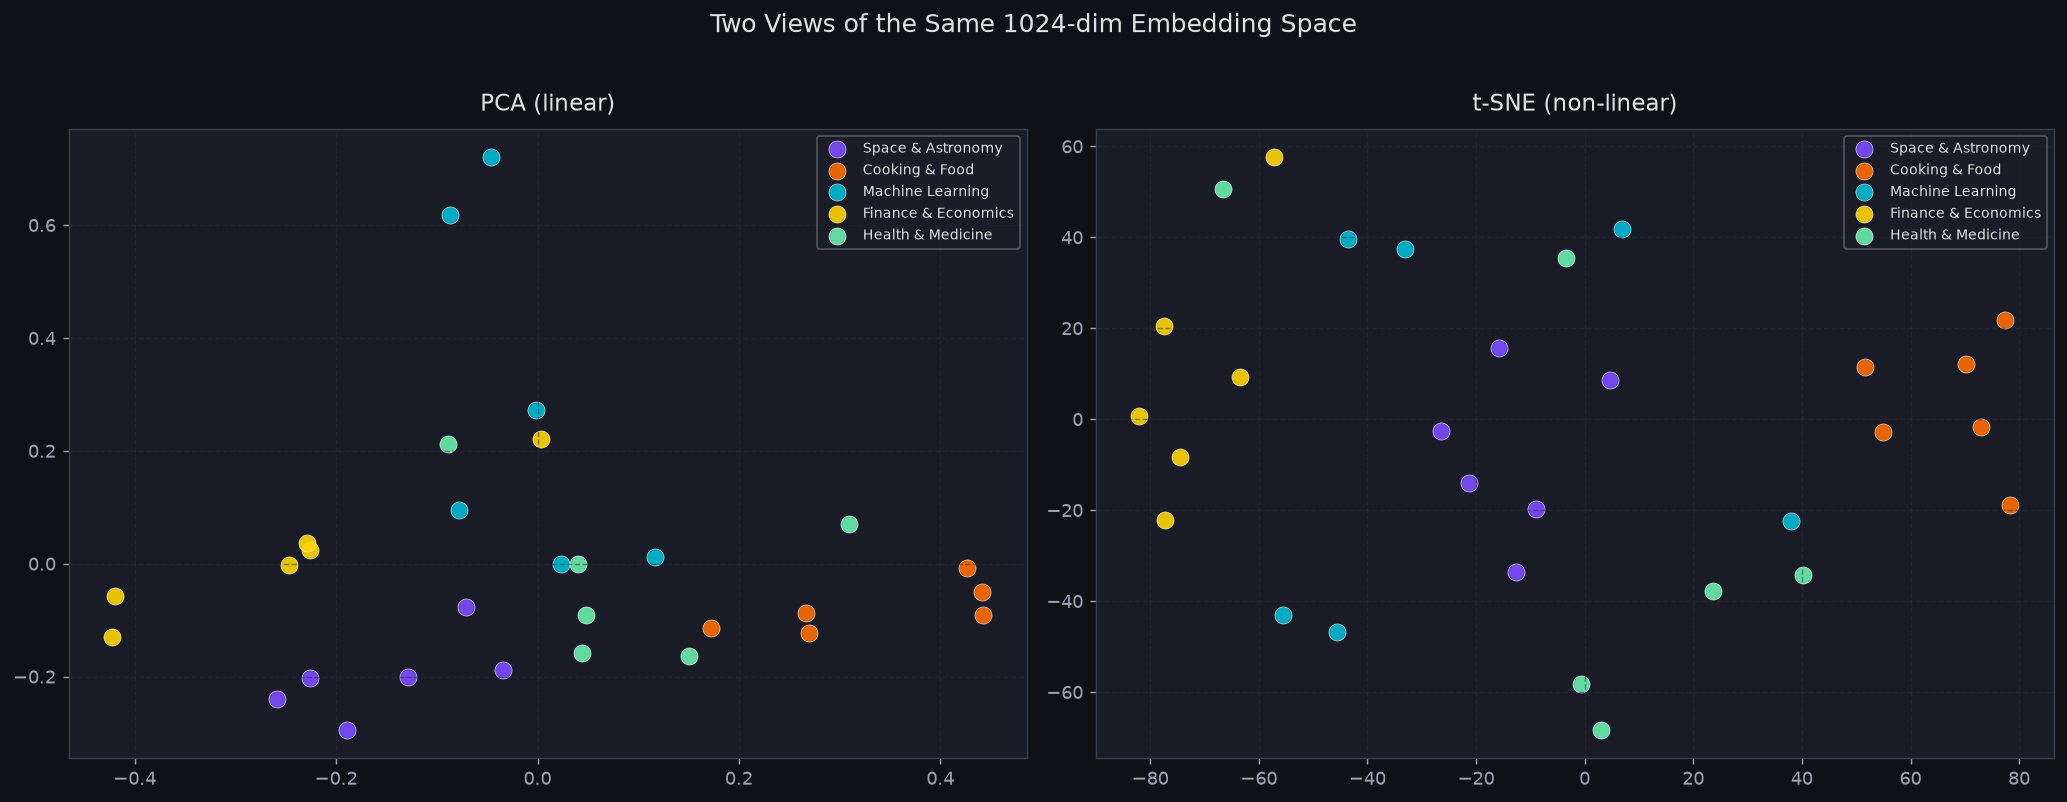

Saved: 03_pca_vs_tsne.png


In [8]:
tsne   = TSNE(n_components=2, perplexity=8, random_state=42, max_iter=1000, learning_rate="auto", init="pca")
coords_tsne = tsne.fit_transform(matrix)   # (30, 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pts, title in [
    (axes[0], coords,      "PCA (linear)"),
    (axes[1], coords_tsne, "t-SNE (non-linear)"),
]:
    for topic, color in palette.items():
        mask = [i for i, l in enumerate(all_labels) if l == topic]
        ax.scatter(pts[mask, 0], pts[mask, 1],
                   c=color, s=90, alpha=0.9, label=topic,
                   edgecolors="white", linewidths=0.3)
    ax.set_title(title, pad=10)
    ax.legend(loc="best", framealpha=0.3, fontsize=8)
    ax.grid(True)

fig.suptitle("Two Views of the Same 1024-dim Embedding Space", fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig("03_pca_vs_tsne.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 03_pca_vs_tsne.png")

## Step 6 — Cosine Similarity Heatmap

For a focused view, we compute the full cosine similarity matrix for one topic group
plus a few off-topic sentences and display it as a heatmap.

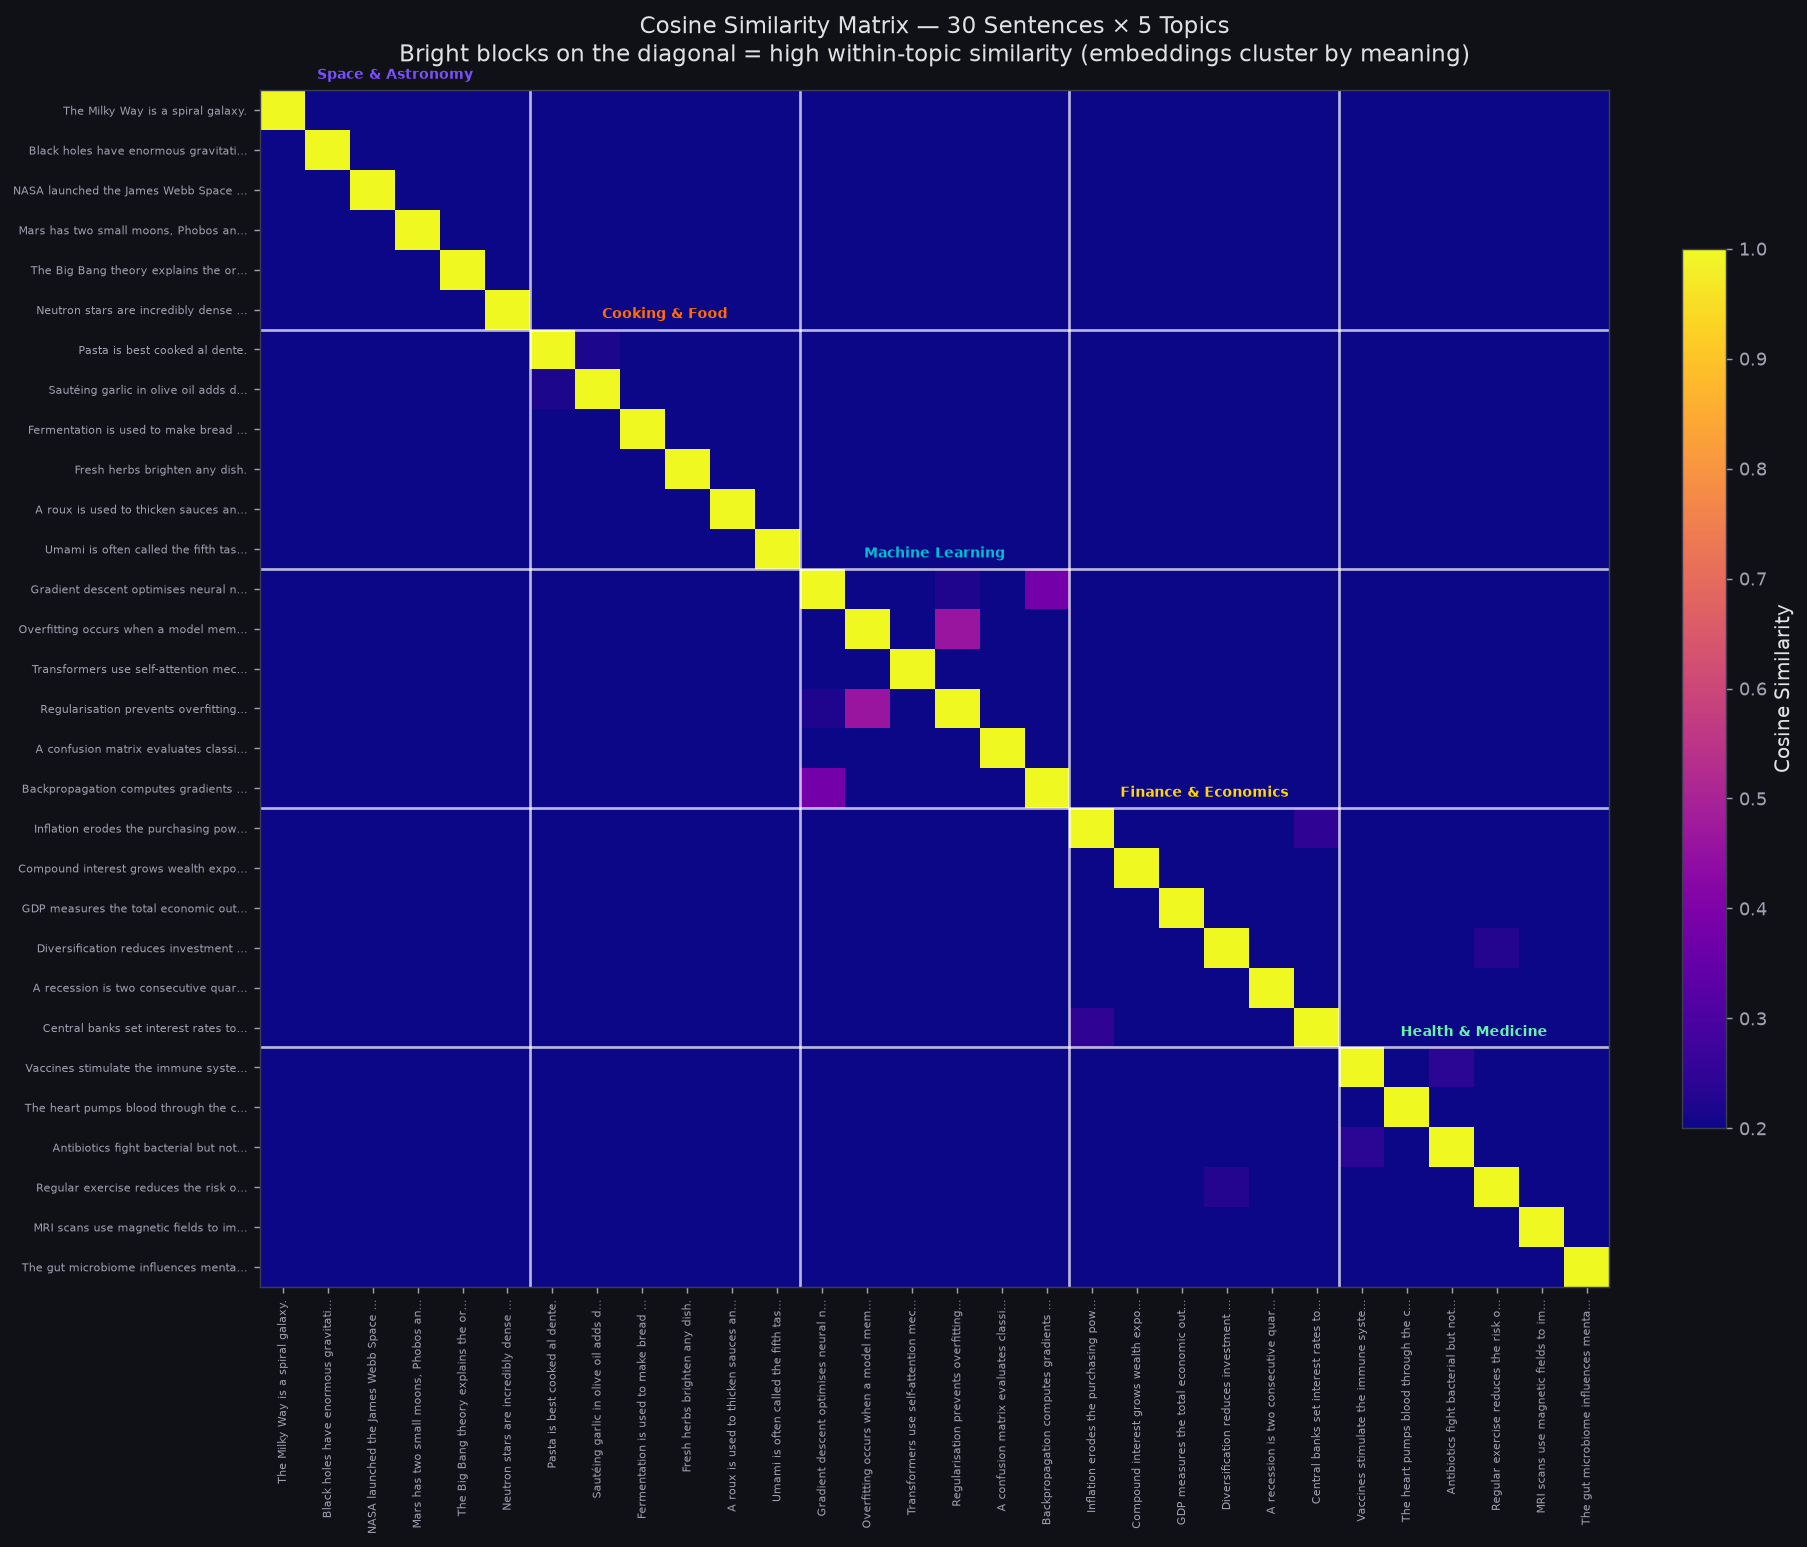

Saved: 04_cosine_heatmap.png


In [9]:
# Use all 30 sentences; cosine similarity is just dot product (already unit-normalised)
sim_matrix = cosine_similarity(matrix)   # (30, 30)

# Short labels for the heatmap axes
short_labels = [s[:35] + "…" if len(s) > 35 else s for s in all_sentences]

# Topic boundary lines
boundaries = []
cumcount = 0
for topic in topic_sentences:
    cumcount += len(topic_sentences[topic])
    boundaries.append(cumcount)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim_matrix, cmap="plasma", vmin=0.2, vmax=1.0, aspect="auto")

plt.colorbar(im, ax=ax, fraction=0.03, label="Cosine Similarity")

# Draw topic boundary lines
for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.5, alpha=0.7)
    ax.axvline(b - 0.5, color="white", linewidth=1.5, alpha=0.7)

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=90, fontsize=6)
ax.set_yticklabels(short_labels, fontsize=6)

# Topic labels on diagonal blocks
pos = 0
for topic, color in palette.items():
    n = len(topic_sentences[topic])
    mid = pos + n / 2 - 0.5
    ax.text(mid, pos - 0.7, topic, color=color, fontsize=8, ha="center", va="bottom",
            fontweight="bold")
    pos += n

ax.set_title(
    "Cosine Similarity Matrix — 30 Sentences × 5 Topics\n"
    "Bright blocks on the diagonal = high within-topic similarity (embeddings cluster by meaning)",
    pad=16
)

fig.tight_layout()
plt.savefig("04_cosine_heatmap.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 04_cosine_heatmap.png")

**Read the heatmap** — Bright (yellow/white) squares appear on the diagonal blocks, where
sentences in the *same topic* compare against each other. Off-diagonal blocks are dark,
meaning cross-topic sentences score low. This is pure geometry — no labels given.

## Step 7 — Semantic Search vs Keyword Search (Live Demo)

We store all 30 sentences in Qdrant, then run a query and compare which documents
each strategy returns and at what score.

In [10]:
import uuid

# ── Connect to Qdrant ─────────────────────────────────────────────────────────
if QDRANT_URL:
    kwargs = {"url": QDRANT_URL}
    if QDRANT_API_KEY:
        kwargs["api_key"] = QDRANT_API_KEY
    qc = QdrantClient(**kwargs)
    print(f"Connected to Qdrant Cloud: {QDRANT_URL}")
else:
    qc = QdrantClient(":memory:")
    print("Using Qdrant in-memory")

COLL = "embeddings_demo"
# Recreate collection
if COLL in [c.name for c in qc.get_collections().collections]:
    qc.delete_collection(COLL)
qc.create_collection(COLL, vectors_config=VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE))

# Index all 30 sentences
points = [
    PointStruct(
        id=str(uuid.uuid4()),
        vector=matrix[i].tolist(),
        payload={"text": all_sentences[i], "topic": all_labels[i]}
    )
    for i in range(len(all_sentences))
]
qc.upsert(collection_name=COLL, points=points)
print(f"Indexed {len(points)} sentences into Qdrant collection '{COLL}'")

Using Qdrant in-memory
Indexed 30 sentences into Qdrant collection 'embeddings_demo'


In [11]:
# ── Semantic search helper ────────────────────────────────────────────────────
def semantic_search(query: str, top_k: int = 6):
    q_vec = embed(query)
    hits  = qc.query_points(collection_name=COLL, query=q_vec.tolist(),
                             limit=top_k, with_payload=True)
    return [(p.payload["text"], p.payload["topic"], p.score) for p in hits.points]


# ── Keyword search helper (simple substring match + Jaccard) ─────────────────
def keyword_search(query: str, top_k: int = 6):
    q_words = set(query.lower().split())
    scored = []
    for sent, topic in zip(all_sentences, all_labels):
        s_words = set(sent.lower().split())
        jacc = len(q_words & s_words) / len(q_words | s_words) if q_words | s_words else 0
        scored.append((sent, topic, jacc))
    scored.sort(key=lambda x: x[2], reverse=True)
    return scored[:top_k]


# ── Run comparison ────────────────────────────────────────────────────────────
QUERY = "neural networks learning from data"

sem_results = semantic_search(QUERY)
kw_results  = keyword_search(QUERY)

print(f"Query: '{QUERY}'")
print()
print("SEMANTIC SEARCH (Qdrant cosine similarity)")
for sent, topic, score in sem_results:
    print(f"  score={score:.3f}  [{topic}]  {sent}")

print()
print("KEYWORD SEARCH (Jaccard word overlap)")
for sent, topic, score in kw_results:
    print(f"  score={score:.3f}  [{topic}]  {sent}")

Query: 'neural networks learning from data'

SEMANTIC SEARCH (Qdrant cosine similarity)
  score=0.313  [Machine Learning]  Gradient descent optimises neural network weights.
  score=0.153  [Machine Learning]  Overfitting occurs when a model memorises training data.
  score=0.125  [Machine Learning]  Backpropagation computes gradients for weight updates.
  score=0.111  [Machine Learning]  Regularisation prevents overfitting in ML models.
  score=0.092  [Space & Astronomy]  The Milky Way is a spiral galaxy.
  score=0.073  [Machine Learning]  Transformers use self-attention mechanisms.

KEYWORD SEARCH (Jaccard word overlap)
  score=0.100  [Machine Learning]  Gradient descent optimises neural network weights.
  score=0.000  [Space & Astronomy]  The Milky Way is a spiral galaxy.
  score=0.000  [Space & Astronomy]  Black holes have enormous gravitational pull.
  score=0.000  [Space & Astronomy]  NASA launched the James Webb Space Telescope.
  score=0.000  [Space & Astronomy]  Mars has two sm

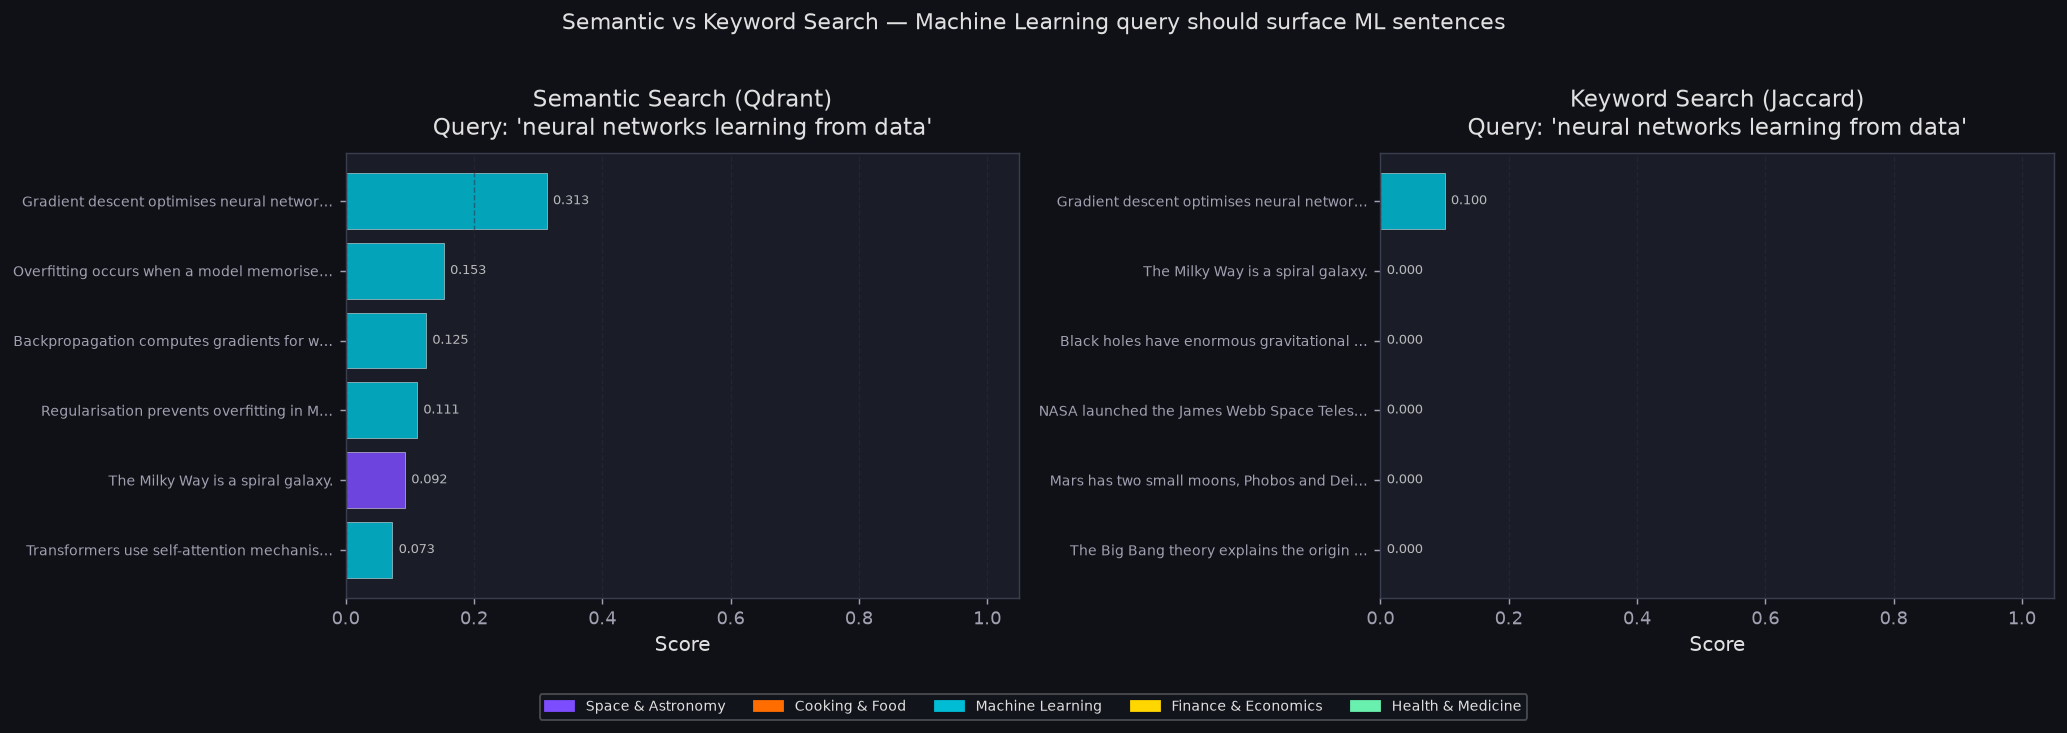

Saved: 05_search_comparison.png


In [12]:
# ── Visualise: head-to-head bar chart ─────────────────────────────────────────
topic_color_map = {
    "Space & Astronomy":   "#7C4DFF",
    "Cooking & Food":      "#FF6D00",
    "Machine Learning":    "#00BCD4",
    "Finance & Economics": "#FFD600",
    "Health & Medicine":   "#69F0AE",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, results, title in [
    (ax1, sem_results, f"Semantic Search (Qdrant)\nQuery: '{QUERY}'"),
    (ax2, kw_results,  f"Keyword Search (Jaccard)\nQuery: '{QUERY}'"),
]:
    texts  = [r[0][:40] + "…" if len(r[0]) > 40 else r[0] for r in results]
    scores = [r[2] for r in results]
    colors = [topic_color_map.get(r[1], "#aaaaaa") for r in results]

    bars = ax.barh(range(len(texts)), scores, color=colors, alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.set_yticks(range(len(texts)))
    ax.set_yticklabels(texts, fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Score")
    ax.set_title(title, pad=10)
    ax.invert_yaxis()
    ax.grid(axis="x")

    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score + 0.01, i, f"{score:.3f}", va="center", fontsize=7, alpha=0.8)

# Topic legend
patches = [mpatches.Patch(color=c, label=t) for t, c in topic_color_map.items()]
fig.legend(handles=patches, loc="lower center", ncol=5, framealpha=0.3,
           fontsize=8, bbox_to_anchor=(0.5, -0.08))

fig.suptitle("Semantic vs Keyword Search — Machine Learning query should surface ML sentences",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.savefig("05_search_comparison.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 05_search_comparison.png")

## Step 8 — Analogy Arithmetic: `king − man + woman ≈ queen`

One of the most famous properties of dense embeddings is that **vector arithmetic**
encodes semantic relationships. We test this directly with real Bedrock API calls.

In [13]:
# ── Analogy probes ────────────────────────────────────────────────────────────
analogy_cases = [
    ("king",   "man",     "woman",   "queen",          ["queen", "princess", "empress", "duchess"]),
    ("Paris",  "France",  "Germany", "Berlin",         ["Berlin", "Munich", "Frankfurt", "Hamburg"]),
    ("doctor", "hospital","school",  "teacher",        ["teacher", "professor", "educator", "principal"]),
    ("hot",    "fire",    "water",   "cold",            ["cold", "ice", "frozen", "cool"]),
]

# Collect all unique words and embed them
all_words = set()
for a, b, c, expected, candidates in analogy_cases:
    all_words.update([a, b, c, expected] + candidates)
all_words = sorted(all_words)

print(f"Embedding {len(all_words)} words for analogy tests...")
word_vecs = embed_batch(all_words)
word_to_vec = {w: word_vecs[i] for i, w in enumerate(all_words)}
print("Done.")

Embedding 28 words for analogy tests...


  10/28 embedded


  20/28 embedded


Done.


In [14]:
def analogy(a, b, c, word_to_vec):
    """Compute a - b + c, return top candidates by cosine similarity."""
    result_vec = word_to_vec[a] - word_to_vec[b] + word_to_vec[c]
    result_vec = result_vec / (np.linalg.norm(result_vec) + 1e-9)

    scored = []
    for w, v in word_to_vec.items():
        if w in (a, b, c):
            continue
        score = float(np.dot(result_vec, v))
        scored.append((w, score))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:5]


print("Analogy results from real Bedrock embeddings:\n")
analogy_results_data = []
for a, b, c, expected, candidates in analogy_cases:
    top5 = analogy(a, b, c, word_to_vec)
    expected_rank = next((i+1 for i, (w, _) in enumerate(top5) if w == expected), None)
    top_word, top_score = top5[0] if top5 else ("-", 0)
    hit = "✓" if top_word == expected else ("~" if expected_rank else "✗")
    print(f"{hit}  {a} - {b} + {c} ≈ {top_word}  (expected: {expected})  "
          f"score={top_score:.4f}  expected_rank={expected_rank}")
    analogy_results_data.append({
        "analogy": f"{a}−{b}+{c}",
        "expected": expected,
        "top5": top5,
        "hit": hit,
    })

Analogy results from real Bedrock embeddings:

✓  king - man + woman ≈ queen  (expected: queen)  score=0.3372  expected_rank=1
✓  Paris - France + Germany ≈ Berlin  (expected: Berlin)  score=0.4153  expected_rank=1
✓  doctor - hospital + school ≈ teacher  (expected: teacher)  score=0.4070  expected_rank=1
~  hot - fire + water ≈ cool  (expected: cold)  score=0.3262  expected_rank=3


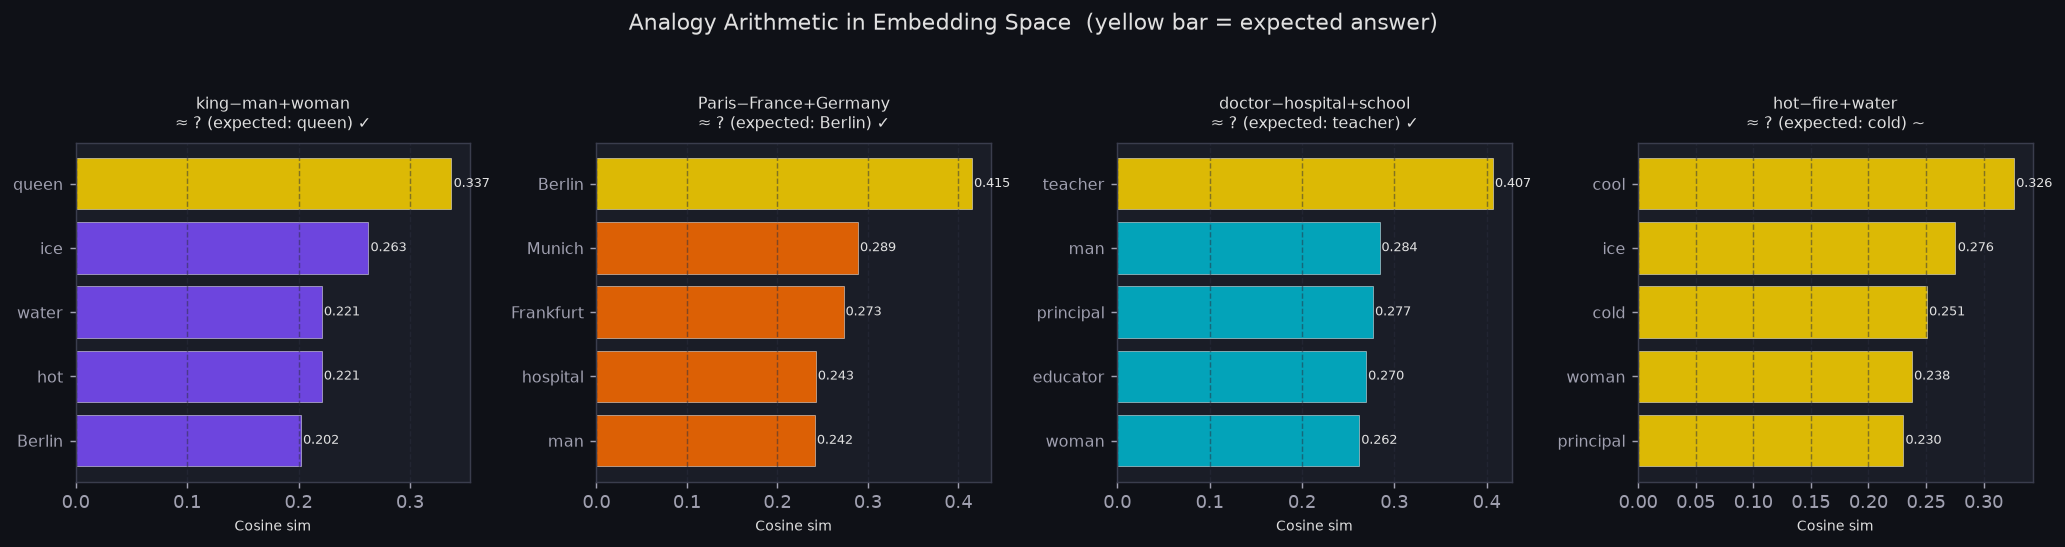

Saved: 06_analogy_arithmetic.png


In [15]:
# ── Visualise top-5 scores for each analogy ───────────────────────────────────
n = len(analogy_results_data)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

bar_palette = ["#7C4DFF", "#FF6D00", "#00BCD4", "#FFD600"]

for ax, data, color in zip(axes, analogy_results_data, bar_palette):
    words  = [r[0] for r in data["top5"]]
    scores = [r[1] for r in data["top5"]]
    bar_colors = ["#FFD600" if w == data["expected"] else color for w in words]

    ax.barh(range(len(words)), scores, color=bar_colors, alpha=0.85,
            edgecolor="white", linewidth=0.3)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"{data['analogy']}\n≈ ? (expected: {data['expected']}) {data['hit']}",
                 fontsize=9, pad=8)
    ax.set_xlabel("Cosine sim", fontsize=8)
    ax.grid(axis="x")
    for i, score in enumerate(scores):
        ax.text(score + 0.002, i, f"{score:.3f}", va="center", fontsize=7)

fig.suptitle(
    "Analogy Arithmetic in Embedding Space  (yellow bar = expected answer)",
    fontsize=12, y=1.04
)
fig.tight_layout()
plt.savefig("06_analogy_arithmetic.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 06_analogy_arithmetic.png")

## Step 9 — Why 1024 Dimensions? Capacity Analysis

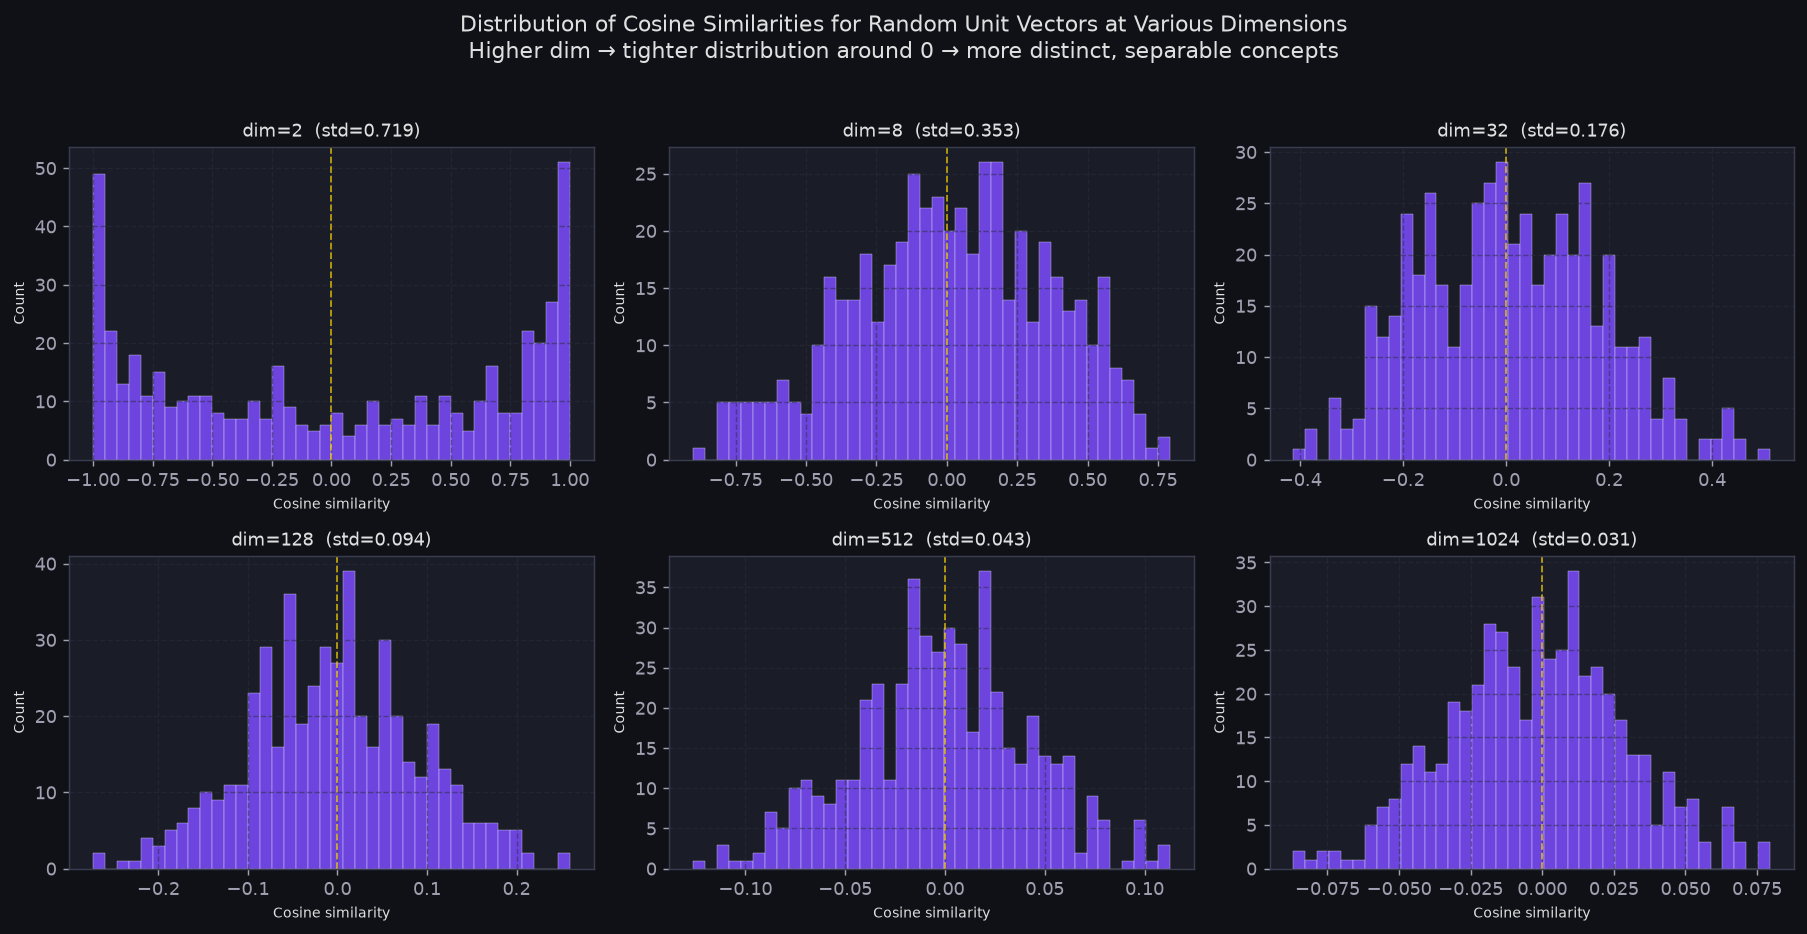

Saved: 07_dimension_capacity.png


In [16]:
# ── How cosine similarity distributes for random unit vectors in high-D ───────
# In low dimensions random vectors can accidentally be similar.
# In high dimensions they concentrate around cosine=0 (orthogonal → independent concepts).

np.random.seed(42)
dims_to_test = [2, 8, 32, 128, 512, 1024]
n_samples    = 1000

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for ax, dim in zip(axes, dims_to_test):
    # Sample random unit vectors
    vecs = np.random.randn(n_samples, dim).astype(np.float32)
    vecs /= np.linalg.norm(vecs, axis=1, keepdims=True)
    # Cosine similarities between consecutive pairs
    sims = (vecs[::2] * vecs[1::2]).sum(axis=1)

    std = sims.std()
    ax.hist(sims, bins=40, color="#7C4DFF", edgecolor="white", linewidth=0.2, alpha=0.85)
    ax.set_title(f"dim={dim}  (std={std:.3f})", fontsize=10)
    ax.set_xlabel("Cosine similarity", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.axvline(0, color="#FFD600", linewidth=1, linestyle="--", alpha=0.7)
    ax.grid(True)

fig.suptitle(
    "Distribution of Cosine Similarities for Random Unit Vectors at Various Dimensions\n"
    "Higher dim → tighter distribution around 0 → more distinct, separable concepts",
    fontsize=12, y=1.02
)
fig.tight_layout()
plt.savefig("07_dimension_capacity.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 07_dimension_capacity.png")

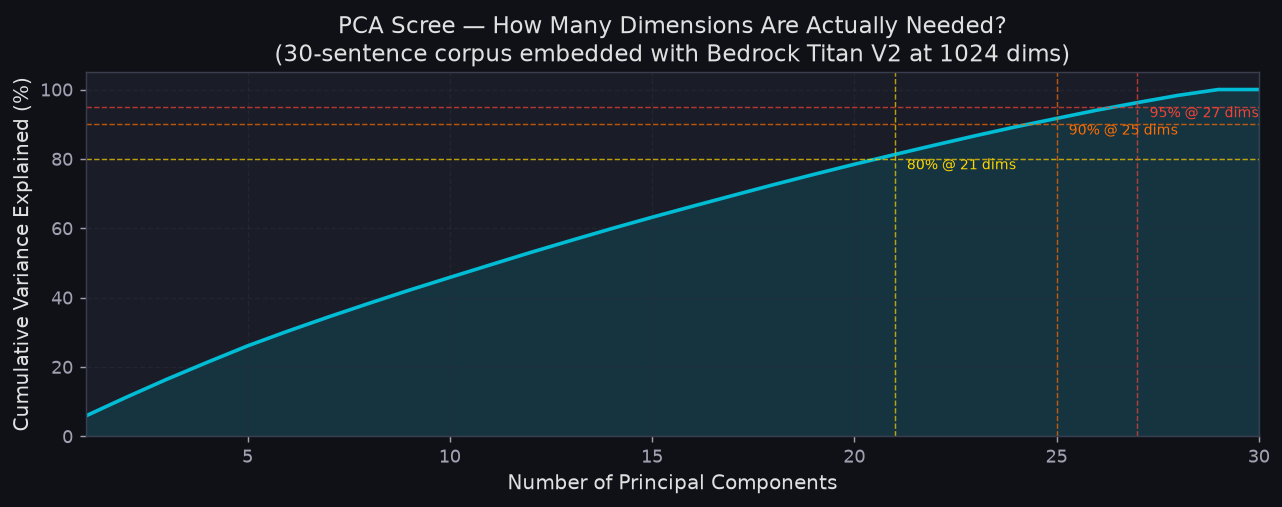

Saved: 08_pca_scree.png


In [17]:
# ── Additional: real embedding dimensionality — how much info per dim? ────────
# Plot the PCA explained-variance curve for the 30-sentence matrix

pca_full = PCA().fit(matrix)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumvar)+1), cumvar * 100, color="#00BCD4", linewidth=2)
ax.fill_between(range(1, len(cumvar)+1), cumvar * 100, alpha=0.15, color="#00BCD4")

for threshold, color in [(80, "#FFD600"), (90, "#FF6D00"), (95, "#F44336")]:
    n_dims = np.searchsorted(cumvar, threshold / 100) + 1
    ax.axhline(threshold, color=color, linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axvline(n_dims,    color=color, linestyle="--", linewidth=0.8, alpha=0.7)
    ax.text(n_dims + 0.3, threshold - 3, f"{threshold}% @ {n_dims} dims",
            color=color, fontsize=8)

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Variance Explained (%)")
ax.set_title(
    "PCA Scree — How Many Dimensions Are Actually Needed?\n"
    "(30-sentence corpus embedded with Bedrock Titan V2 at 1024 dims)"
)
ax.set_xlim(1, min(30, len(cumvar)))
ax.set_ylim(0, 105)
ax.grid(True)

fig.tight_layout()
plt.savefig("08_pca_scree.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: 08_pca_scree.png")

## Step 10 — RAG Without Embeddings vs RAG With Embeddings

A final, concrete demo: store our 30 sentences in Qdrant, then show how a semantically
phrased query (zero keyword overlap with the answer) retrieves the right result via
embeddings but fails with keyword search.

In [18]:
# Queries deliberately phrased to share NO words with the stored sentences
rag_demos = [
    {
        "query": "stellar remnants with extreme density after supernova explosion",
        "expected_topic": "Space & Astronomy",
        "notes": "Contains 'dense', 'stellar remnants' — paraphrase of stored sentences",
    },
    {
        "query": "preventing model memorisation of training examples",
        "expected_topic": "Machine Learning",
        "notes": "Paraphrase of overfitting/regularisation concepts",
    },
    {
        "query": "microorganisms in the digestive tract affect wellbeing",
        "expected_topic": "Health & Medicine",
        "notes": "Paraphrase of gut microbiome sentence",
    },
]

for demo in rag_demos:
    sem = semantic_search(demo["query"], top_k=3)
    kw  = keyword_search(demo["query"],  top_k=3)

    print(f"Query: '{demo['query']}'")
    print(f"Note : {demo['notes']}")
    print(f"Expected topic: {demo['expected_topic']}")
    print()
    print("  SEMANTIC top-3:")
    for sent, topic, score in sem:
        flag = " ← CORRECT" if topic == demo["expected_topic"] else ""
        print(f"    [{score:.3f}] [{topic}]{flag}  {sent}")
    print("  KEYWORD top-3:")
    for sent, topic, score in kw:
        flag = " ← CORRECT" if topic == demo["expected_topic"] else ""
        print(f"    [{score:.3f}] [{topic}]{flag}  {sent}")
    print("-" * 80)

Query: 'stellar remnants with extreme density after supernova explosion'
Note : Contains 'dense', 'stellar remnants' — paraphrase of stored sentences
Expected topic: Space & Astronomy

  SEMANTIC top-3:
    [0.496] [Space & Astronomy] ← CORRECT  Neutron stars are incredibly dense stellar remnants.
    [0.068] [Machine Learning]  Overfitting occurs when a model memorises training data.
    [0.054] [Finance & Economics]  GDP measures the total economic output of a country.
  KEYWORD top-3:
    [0.071] [Space & Astronomy] ← CORRECT  Neutron stars are incredibly dense stellar remnants.
    [0.000] [Space & Astronomy] ← CORRECT  The Milky Way is a spiral galaxy.
    [0.000] [Space & Astronomy] ← CORRECT  Black holes have enormous gravitational pull.
--------------------------------------------------------------------------------


Query: 'preventing model memorisation of training examples'
Note : Paraphrase of overfitting/regularisation concepts
Expected topic: Machine Learning

  SEMANTIC top-3:
    [0.497] [Machine Learning] ← CORRECT  Overfitting occurs when a model memorises training data.
    [0.456] [Machine Learning] ← CORRECT  Regularisation prevents overfitting in ML models.
    [0.113] [Machine Learning] ← CORRECT  Gradient descent optimises neural network weights.
  KEYWORD top-3:
    [0.167] [Machine Learning] ← CORRECT  Overfitting occurs when a model memorises training data.
    [0.083] [Finance & Economics]  Inflation erodes the purchasing power of money.
    [0.077] [Space & Astronomy]  The Big Bang theory explains the origin of the universe.
--------------------------------------------------------------------------------


Query: 'microorganisms in the digestive tract affect wellbeing'
Note : Paraphrase of gut microbiome sentence
Expected topic: Health & Medicine

  SEMANTIC top-3:
    [0.642] [Health & Medicine] ← CORRECT  The gut microbiome influences mental and physical health.
    [0.153] [Cooking & Food]  Umami is often called the fifth taste.
    [0.122] [Machine Learning]  A confusion matrix evaluates classification performance.
  KEYWORD top-3:
    [0.083] [Machine Learning]  Regularisation prevents overfitting in ML models.
    [0.077] [Space & Astronomy]  The Milky Way is a spiral galaxy.
    [0.077] [Space & Astronomy]  NASA launched the James Webb Space Telescope.
--------------------------------------------------------------------------------


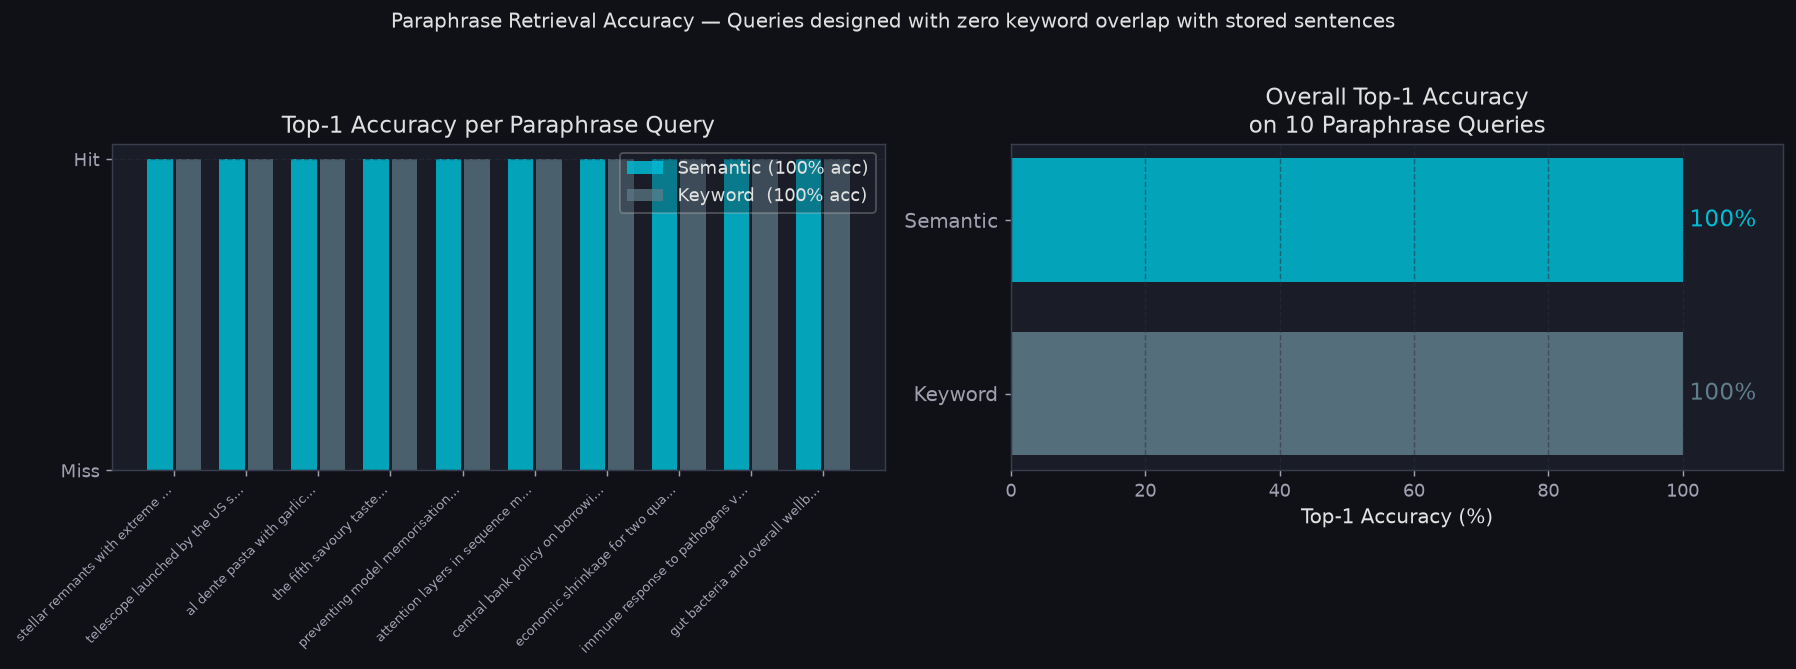

Semantic accuracy: 100%
Keyword  accuracy: 100%
Saved: 09_rag_accuracy.png


In [19]:
# ── Visualise: topic accuracy at top-1 for 10 paraphrase queries ─────────────
extended_queries = [
    ("stellar remnants with extreme density",          "Space & Astronomy"),
    ("telescope launched by the US space agency",      "Space & Astronomy"),
    ("al dente pasta with garlic",                     "Cooking & Food"),
    ("the fifth savoury taste",                        "Cooking & Food"),
    ("preventing model memorisation",                  "Machine Learning"),
    ("attention layers in sequence models",            "Machine Learning"),
    ("central bank policy on borrowing costs",         "Finance & Economics"),
    ("economic shrinkage for two quarters",            "Finance & Economics"),
    ("immune response to pathogens via injection",     "Health & Medicine"),
    ("gut bacteria and overall wellbeing",             "Health & Medicine"),
]

sem_hits, kw_hits = [], []
for query, expected_topic in extended_queries:
    s_top = semantic_search(query, top_k=1)
    k_top = keyword_search(query,  top_k=1)
    sem_hits.append(1 if s_top and s_top[0][1] == expected_topic else 0)
    kw_hits.append( 1 if k_top and k_top[0][1] == expected_topic else 0)

sem_acc = sum(sem_hits) / len(sem_hits) * 100
kw_acc  = sum(kw_hits)  / len(kw_hits)  * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-query hit grid
ax = axes[0]
q_labels = [q[:30] + "…" for q, _ in extended_queries]
x = np.arange(len(q_labels))
ax.bar(x - 0.2, sem_hits, 0.35, label=f"Semantic ({sem_acc:.0f}% acc)",
       color="#00BCD4", alpha=0.85)
ax.bar(x + 0.2, kw_hits,  0.35, label=f"Keyword  ({kw_acc:.0f}% acc)",
       color="#607D8B", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(q_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Miss", "Hit"])
ax.set_title("Top-1 Accuracy per Paraphrase Query")
ax.legend(framealpha=0.3)
ax.grid(axis="y")

# Right: summary accuracy donut
ax2 = axes[1]
for i, (acc, color, label) in enumerate([
    (sem_acc, "#00BCD4", f"Semantic\n{sem_acc:.0f}%"),
    (kw_acc,  "#607D8B", f"Keyword\n{kw_acc:.0f}%"),
]):
    y_pos = 0.65 - i * 0.35
    ax2.barh([y_pos], [acc],        height=0.25, color=color,    alpha=0.85, label=label)
    ax2.barh([y_pos], [100 - acc],  height=0.25, color="#2a2d3d", left=[acc])
    ax2.text(acc + 1, y_pos, f"{acc:.0f}%", va="center", fontsize=13, color=color)

ax2.set_xlim(0, 115)
ax2.set_yticks([0.3, 0.65])
ax2.set_yticklabels(["Keyword", "Semantic"], fontsize=11)
ax2.set_xlabel("Top-1 Accuracy (%)")
ax2.set_title("Overall Top-1 Accuracy\non 10 Paraphrase Queries")
ax2.grid(axis="x")

fig.suptitle(
    "Paraphrase Retrieval Accuracy — Queries designed with zero keyword overlap with stored sentences",
    fontsize=11, y=1.02
)
fig.tight_layout()
plt.savefig("09_rag_accuracy.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Semantic accuracy: {sem_acc:.0f}%")
print(f"Keyword  accuracy: {kw_acc:.0f}%")
print("Saved: 09_rag_accuracy.png")

## Step 11 — Cleanup

In [20]:
qc.delete_collection(COLL)
print(f"Collection '{COLL}' deleted.")

Collection 'embeddings_demo' deleted.


## Summary — Why We Need Embeddings

| Property | Keyword search | Embedding search |
|----------|---------------|------------------|
| Matches synonyms | ✗ | ✓ |
| Matches paraphrases | ✗ | ✓ |
| Matches medical/legal jargon ↔ plain language | ✗ | ✓ |
| Handles multilingual | ✗ | ✓ (multilingual models) |
| Supports analogy reasoning | ✗ | ✓ |
| Speed at scale | Fast (inverted index) | Fast (ANN, e.g. Qdrant HNSW) |
| Interpretable | ✓ | Harder |

### The one-sentence answer
> Embeddings convert text into a high-dimensional vector space where **geometric
> proximity = semantic similarity**, enabling retrieval by *meaning* rather than
> character matching — which is the essential primitive that makes RAG work.

### What makes Bedrock Titan V2 useful here
- 1024 dimensions — enough capacity to distinguish millions of distinct concepts
- Unit-normalised output — cosine similarity = dot product (fast, cheap)
- AWS-native — same IAM, same region, same bill as the rest of your Bedrock stack

### Next notebook
**01 — Simple RAG** builds on these embeddings to implement the full index-retrieve-generate pipeline.